ASW_VS_ASWO CON LOGFC=2

1 
2 
3 
4 
5 
6 
7 
8 
9 


using counts and average transcript lengths from tximport

estimating size factors

using 'avgTxLength' from assays(dds), correcting for library size

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,regulation
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
pelegrina_gene1001932_i1,10.666785,-3.020645,0.72473926,-4.167905,3.074115e-05,4.072311e-04,Subexpresado
pelegrina_gene1002385_i1,6.616846,4.956034,1.47686150,3.355788,7.913930e-04,7.488448e-03,Sobreexpresado
pelegrina_gene1002435_i1,11.599164,3.438738,0.87207223,3.943181,8.040806e-05,9.738426e-04,Sobreexpresado
pelegrina_gene1002518_i1,13527.575205,2.082957,0.05441701,38.277688,1.440695e-320,1.585446e-316,Sobreexpresado
pelegrina_gene1002660_i1,3.321006,4.982464,1.59880767,3.116362,1.830973e-03,1.557028e-02,Sobreexpresado
pelegrina_gene1002754_i1,6.347081,2.852550,1.04190363,2.737825,6.184689e-03,4.362847e-02,Sobreexpresado



out of 121085 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 11119, 9.2%
LFC < 0 (down)     : 9632, 8%
outliers [1]       : 33, 0.027%
low counts [2]     : 0, 0%
(mean count < 2)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



[1] 4805

# A tibble: 3 × 2
  regulation            n
  <chr>             <int>
1 No significativo 116237
2 Sobreexpresado     3701
3 Subexpresado       1104


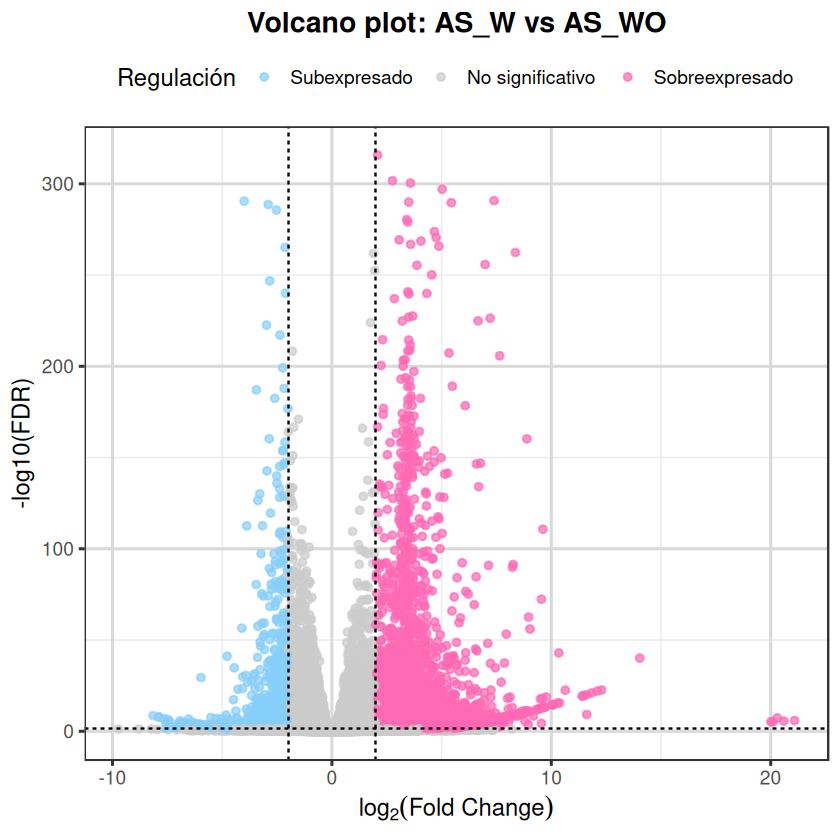

Genes fondo: 44035 
DEGs: 4805 
DEGs con KEGG: 435 
                                                 Description Count GeneRatio
map00940                        Phenylpropanoid biosynthesis    24    24/435
map00073                Cutin, suberine and wax biosynthesis     7     7/435
map05145                                       Toxoplasmosis     9     9/435
map00999 Biosynthesis of various plant secondary metabolites    10    10/435
map00946                           Degradation of flavonoids     6     6/435
map00901                        Indole alkaloid biosynthesis     3     3/435
map04360                                       Axon guidance    10    10/435
map00565                              Ether lipid metabolism     8     8/435
map01310                                      Nitrogen cycle     3     3/435
map00062                               Fatty acid elongation     7     7/435
map04928 Parathyroid hormone synthesis, secretion and action     9     9/435
map04919                

agg_record_bab42cd07998 
                      2

Warning message in fortify(object, showCategory = showCategory, by = x, ...):
“Arguments in `...` must be used.
✖ Problematic argument:
• by = x
ℹ Did you misspell an argument name?”


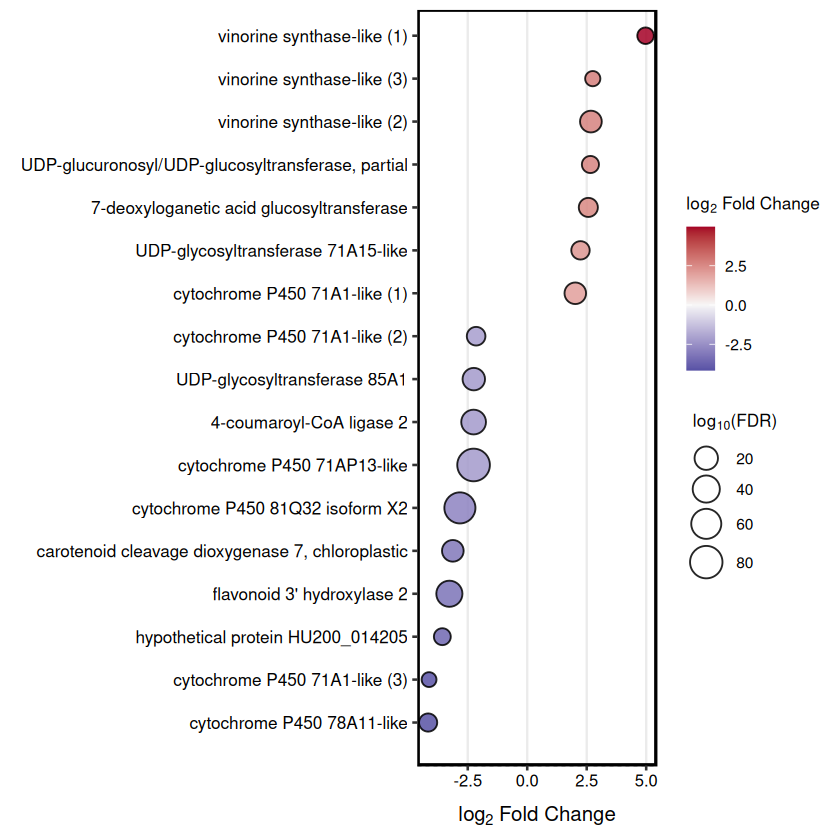

Note: Only KEGG ortholog gene ID is supported, make sure it looks like "K01488"!

Note: Mapping via KEGG gene ID (not Entrez) is supported for this species,
it looks like "K01488"!

Info: Working in directory /home/pazzz/Escritorio/GTF/DE_alstroemeria/DEA

Info: Writing image file ko00906.pathview.png



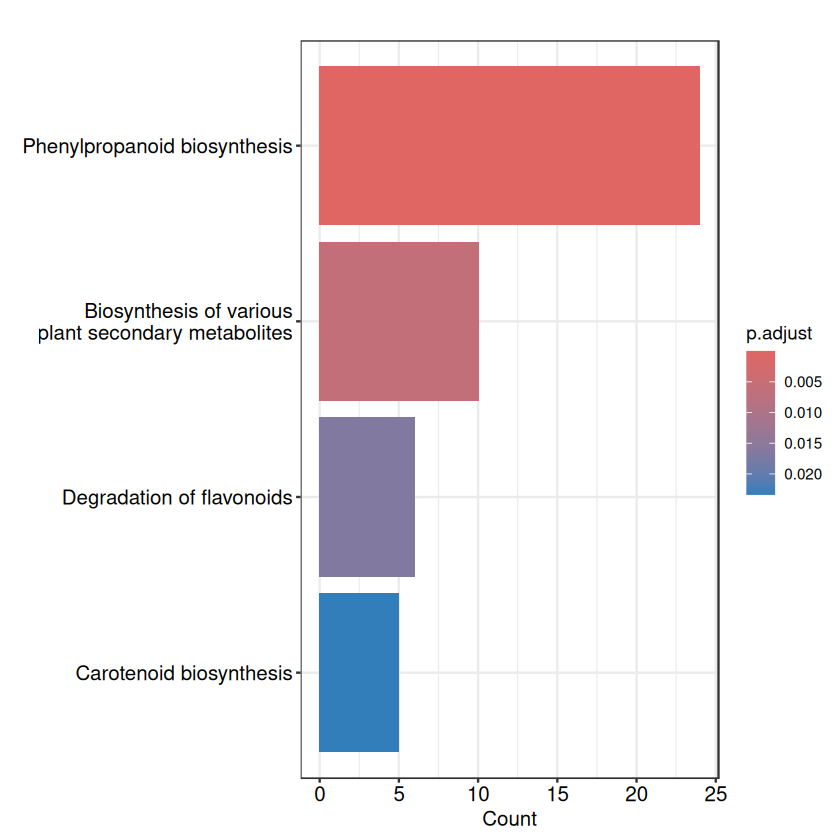

In [ ]:
#####################################################
# ASW_VS_ASWO CON LOGFC=2
####################################################
setwd("/home/pazzz/Escritorio/GTF/DE_alstroemeria/DEA")

library(tximport)
library(DESeq2)
library(dplyr)
library(ggplot2)

# ===============================
# 1. Muestras
# ===============================
samples <- c(
  "AS_WO_R1","AS_WO_R2","AS_WO_R3",
  "AS_W_R1","AS_W_R2","AS_W_R3",
  "CS_W_R1","CS_W_R2","CS_W_R3"
)

files <- file.path("Counts_2", paste0(samples, ".sf"))
names(files) <- samples

# ===============================
# 2. Importación
# ===============================
txi <- tximport(
  files,
  type = "salmon",
  txOut = TRUE,
  importer = function(x) {
    read.delim(x, check.names = FALSE) %>%
      arrange(Name)
  }
)

# ===============================
# 3. Metadata
# ===============================
coldata <- data.frame(
  row.names = samples,
  condition = c(
    "AS_WO","AS_WO","AS_WO",
    "AS_W","AS_W","AS_W",
    "CS_W","CS_W","CS_W"
  )
)

coldata$condition <- factor(
  coldata$condition,
  levels = c("AS_WO", "AS_W", "CS_W")
)

# ===============================
# 4. Crear objeto DESeq2
# ===============================
dds <- DESeqDataSetFromTximport(
  txi,
  colData = coldata,
  design = ~ condition
)

# ===============================
# 5. Filtrado
# ===============================
dds <- dds[rowSums(counts(dds) >= 5) >= 3, ]

# ===============================
# 6. DESeq
# ===============================
dds <- DESeq(dds)

# ===============================
# 7. Resultados
# ===============================
res_ASW_vs_ASWO <- results(
  dds,
  contrast = c("condition", "AS_W", "AS_WO")
)

# ===============================
# 8. Dataframe + clasificación
# ===============================
lfc_cutoff <- 2
padj_cutoff <- 0.05

res_df <- as.data.frame(res_ASW_vs_ASWO)

res_filtrado <- res_df %>%
  filter(!is.na(padj), padj > 0) %>%
  mutate(regulation = case_when(
    padj < padj_cutoff & log2FoldChange >= lfc_cutoff  ~ "Sobreexpresado",
    padj < padj_cutoff & log2FoldChange <= -lfc_cutoff ~ "Subexpresado",
    TRUE ~ "No significativo"
  )) %>%
  filter(
    padj < padj_cutoff,
    abs(log2FoldChange) >= lfc_cutoff
  )

# ===============================
# 9. Output
# ===============================
head(res_filtrado)
summary(res_ASW_vs_ASWO)
nrow(res_filtrado)

write.csv(res_filtrado, "DEG_ASW_vs_ASWO_logFC2.csv")

# ===============================
# 10. Volcano plot
# ===============================
res_plot <- res_df %>%
  filter(!is.na(padj), padj > 0) %>%
  mutate(regulation = case_when(
    padj < padj_cutoff & log2FoldChange >= lfc_cutoff  ~ "Sobreexpresado",
    padj < padj_cutoff & log2FoldChange <= -lfc_cutoff ~ "Subexpresado",
    TRUE ~ "No significativo"
  ))

# ===============================
# Conteo por categoría
# ===============================
conteo_genes <- res_plot %>%
  group_by(regulation) %>%
  summarise(n = n())

print(conteo_genes)

# ===============================
# Orden de la leyenda
# ===============================
res_plot$regulation <- factor(
  res_plot$regulation,
  levels = c("Subexpresado", "No significativo", "Sobreexpresado")
)

# ===============================
# 11. Genes de pigmentos
# ===============================
genes_interes <- c(
  "pelegrina_gene1170725_i2",
  "pelegrina_gene162036_i1",
  "pelegrina_gene1904850_i1",
  "pelegrina_gene1039844_i1",
  "pelegrina_gene843791_i2",
  "pelegrina_gene1313581_i1",
  "pelegrina_gene1478299_i1",
  "pelegrina_gene1913168_i5",
  "pelegrina_gene1168858_i3",
  "pelegrina_gene1329388_i7",
  "pelegrina_gene1911193_i2",
  "pelegrina_gene846247_i2",
  "pelegrina_gene829540_i1",
  "pelegrina_gene24054_i2",
  "pelegrina_gene1197619_i3",
  "pelegrina_gene15924_i6",
  "pelegrina_gene1314155_i6"



)


# ===============================
# Agregar columna de highlight
# ===============================
res_plot$gene <- rownames(res_plot)

res_plot$highlight <- ifelse(
  res_plot$gene %in% genes_interes,
  "Pigmentos",
  "Otros"
)

# ===============================
# Volcano plot
# ===============================
p1 <- ggplot(res_plot, aes(x = log2FoldChange, y = -log10(padj))) +
  geom_point(
    aes(color = regulation),
    alpha = 0.7,
    size = 1.5
  ) +
  geom_vline(
    xintercept = c(-lfc_cutoff, lfc_cutoff),
    linetype = "dashed",
    linewidth = 0.5
  ) +
  geom_hline(
    yintercept = -log10(padj_cutoff),
    linetype = "dashed",
    linewidth = 0.5
  ) +
  scale_color_manual(values = c(
    "Subexpresado" = "#87CEFA",
    "No significativo" = "grey80",
    "Sobreexpresado" = "#FF69B4"
  )) +
  labs(
    title = "Volcano plot: AS_W vs AS_WO",
    x = expression(log[2]("Fold Change")),
    y = "-log10(FDR)",
    color = "Regulación"
  ) +
  theme_bw(base_size = 14) +
  theme(
    panel.grid.major = element_line(color = "grey85"),
    panel.grid.minor = element_line(color = "grey92"),
    legend.position = "top",
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

# ===============================
# Guardar volcano plot
# ===============================
ggsave(
  filename = "Volcano_ASW_vs_ASWOlogFC2.png",
  plot = p1,
  width = 10,
  height = 8,
  dpi = 300
)

# Mostrar plot
print(p1)

# ===============================
# Genes de interés
# ===============================
genes_interes <- c(
  "pelegrina_gene1170725_i2",
  "pelegrina_gene162036_i1",
  "pelegrina_gene1904850_i1",
  "pelegrina_gene1039844_i1",
  "pelegrina_gene843791_i2",
  "pelegrina_gene1313581_i1",
  "pelegrina_gene1478299_i1",
  "pelegrina_gene1913168_i5",
  "pelegrina_gene1168858_i3",
  "pelegrina_gene1329388_i7",
  "pelegrina_gene1911193_i2",
  "pelegrina_gene846247_i2",
  "pelegrina_gene829540_i1",
  "pelegrina_gene24054_i2",
  "pelegrina_gene1197619_i3",
  "pelegrina_gene15924_i6",
  "pelegrina_gene1314155_i6"
)

# ===============================
# Descripciones
# ===============================
descripciones <- data.frame(
  gene = c(
  "pelegrina_gene1170725_i2",
  "pelegrina_gene162036_i1",
  "pelegrina_gene1904850_i1",
  "pelegrina_gene1039844_i1",
  "pelegrina_gene843791_i2",
  "pelegrina_gene1313581_i1",
  "pelegrina_gene1478299_i1",
  "pelegrina_gene1913168_i5",
  "pelegrina_gene1168858_i3",
  "pelegrina_gene1329388_i7",
  "pelegrina_gene1911193_i2",
  "pelegrina_gene846247_i2",
  "pelegrina_gene829540_i1",
  "pelegrina_gene24054_i2",
  "pelegrina_gene1197619_i3",
  "pelegrina_gene15924_i6",
  "pelegrina_gene1314155_i6"
  ),

  descripcion = c(
    "UDP-glycosyltransferase 85A1 [Apostasia shenzhenica]",
    "cytochrome P450 71A1-like [Zingiber officinale].",
    "vinorine synthase-like [Papaver somniferum].",
    "UDP-glucuronosyl/UDP-glucosyltransferase, partial [Trema orientale]",
    "7-deoxyloganetic acid glucosyltransferase [Beta vulgaris subsp. Vulgaris].",
    "flavonoid 3' hydroxylase 2 [Euphorbia maculata].",
    "cytochrome P450 78A11-like [Typha latifolia].",
    "vinorine synthase-like [Papaver somniferum].",
    "vinorine synthase-like [Papaver somniferum].",
    "carotenoid cleavage dioxygenase 7, chloroplastic [Cocos nucifera]",
    "cytochrome P450 71AP13-like [Dioscorea cayenensis subsp.  Rotundata].",
    "cytochrome P450 81Q32 isoform X2 [Ziziphus jujuba].",
    "4-coumaroyl-CoA ligase 2 [Crocosmia x crocosmiiflora]",
    "LOW QUALITY PROTEIN: UDP-glycosyltransferase 71A15-like [Asparagus officinalis].",
    "LOW QUALITY PROTEIN: cytochrome P450 71A1-like [Setaria italica].",
    "hypothetical protein HU200_014205 [Digitaria exilis]",
    "cytochrome P450 71A1-like [Dendrobium catenatum]."
    
  )
)
# ==============================================================================
# Subset resultados y agregar descripciones
# ==============================================================================
subset_res <- res_df[rownames(res_df) %in% genes_interes, ]
subset_res$gene <- rownames(subset_res)

subset_res <- merge(subset_res, descripciones, by = "gene")

# Filtrado preventivo de NAs
subset_res <- subset_res %>% filter(!is.na(padj), padj > 0)

# ==============================================================================
# Limpieza Avanzada de Descripciones (Nivel Publicación)
# ==============================================================================
subset_res$descripcion_limpia <- sub("^LOW QUALITY PROTEIN:\\s*", "", subset_res$descripcion)

subset_res$descripcion_limpia <- sub("\\s*\\[.*\\]", "", subset_res$descripcion_limpia)
subset_res$descripcion_limpia <- sub("\\.$", "", subset_res$descripcion_limpia)

# ==============================================================================
# SOLUCCIÓN A DUPLICADOS
# ==============================================================================
subset_res <- subset_res %>%
  group_by(descripcion_limpia) %>%
  mutate(
    descripcion_grafico = if(n() > 1) {
      paste0(descripcion_limpia, " (", row_number(), ")")
    } else {
      descripcion_limpia
    }
  ) %>%
  ungroup()

# ==============================================================================
# Ordenar dataframe y asignar factores únicos
# ==============================================================================
subset_res <- subset_res[order(subset_res$log2FoldChange), ]

subset_res$label <- factor(
  subset_res$descripcion_grafico, 
  levels = subset_res$descripcion_grafico
)

# ==============================================================================
# Bubble plot
# ==============================================================================
p2 <- ggplot(
  subset_res,
  aes(
    x = label,          
    y = log2FoldChange,
    fill = log2FoldChange,  
    size = -log10(padj)
  )
) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray60", linewidth = 0.4) +
  
  geom_point(shape = 21, color = "black", alpha = 0.85, stroke = 0.6) +
  
  coord_flip() +
  
  scale_fill_gradient2(
    low = "#313695",    
    mid = "#f7f7f7",     
    high = "#a50026",    
    midpoint = 0,
    name = expression(log[2] * " Fold Change")
  ) +
  
  scale_size_continuous(
    range = c(3.5, 8.5), 
    name = expression(-log[10] * "(FDR)")
  ) +
  
  labs(
    x = NULL, 
    y = expression(log[2] * " Fold Change")
  ) +
  
  theme_bw(base_size = 12) +
  theme(
    panel.grid.major.x = element_line(color = "gray92", linewidth = 0.5),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
    

    axis.text.x = element_text(color = "black"),
    axis.text.y = element_text(color = "black", size = 10), 
    axis.title.x = element_text(face = "bold", margin = margin(t = 10)),
   
    legend.position = "right",
    legend.title = element_text(size = 10, face = "bold"),
    legend.text = element_text(size = 9),
    legend.background = element_blank(),
    legend.box.background = element_blank()
  )

ggsave(
  filename = "BubblePlot_PigmentGenes_Set3_clean.png",
  plot = p2,
  width = 9.5,
  height = 6.0, 
  dpi = 300,
  bg = "white"
)


print(p2)

# =====================================================
# ENRIQUECIMIENTO KEGG
# =====================================================

library(clusterProfiler)
library(enrichplot)

# =====================================================
# Gene -> KO
# =====================================================

ko_gene <- read.delim(
  "KO.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(ko_gene) <- c("gene","KO")

ko_gene$gene <- sub(
  "\\.p[0-9]+$",
  "",
  ko_gene$gene
)

# =====================================================
# KO -> Pathway
# =====================================================

ko2path <- read.delim(
  "ko2pathway.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(ko2path) <- c(
  "KO",
  "Pathway"
)

ko2path$KO <- sub("^ko:", "", ko2path$KO)
ko2path$Pathway <- sub("^path:", "", ko2path$Pathway)

# =====================================================
# Gene -> KO -> Pathway
# =====================================================

gene2path <- merge(
  ko_gene,
  ko2path,
  by = "KO"
)

# convertir koXXXXX a mapXXXXX
gene2path$Pathway <- sub(
  "^ko",
  "map",
  gene2path$Pathway
)

# eliminar duplicados
gene2path <- gene2path %>%
  distinct(gene, Pathway, .keep_all = TRUE)

# =====================================================
# Nombres de pathways
# =====================================================

pathway_names <- read.delim(
  "pathway_names.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(pathway_names) <- c(
  "Pathway",
  "Description"
)

pathway_names$Pathway <- sub(
  "^path:",
  "",
  pathway_names$Pathway
)

# =====================================================
# TERM2GENE
# =====================================================

TERM2GENE <- gene2path %>%
  select(Pathway, gene) %>%
  distinct()

TERM2NAME <- pathway_names %>%
  select(Pathway, Description) %>%
  distinct()

# eliminar pathways demasiado pequeños
TERM2GENE <- TERM2GENE %>%
  group_by(Pathway) %>%
  filter(n() >= 5) %>%
  ungroup()

# =====================================================
# Universo
# =====================================================

background_genes <- unique(
  TERM2GENE$gene
)

cat(
  "Genes fondo:",
  length(background_genes),
  "\n"
)

# =====================================================
# DEGs
# =====================================================

deg_genes <- rownames(res_filtrado)

cat(
  "DEGs:",
  length(deg_genes),
  "\n"
)

deg_genes_kegg <- intersect(
  deg_genes,
  background_genes
)

cat(
  "DEGs con KEGG:",
  length(deg_genes_kegg),
  "\n"
)

if(length(deg_genes_kegg) < 10){
  stop("Muy pocos DEGs anotados con KEGG")
}

# =====================================================
# Enrichment
# =====================================================

kegg_enrich <- enricher(
  gene = deg_genes_kegg,
  universe = background_genes,
  TERM2GENE = TERM2GENE,
  TERM2NAME = TERM2NAME,
  pAdjustMethod = "BH",
  pvalueCutoff = 0.05,
  qvalueCutoff = 0.20
)

if(is.null(kegg_enrich)){
  stop("No se encontraron rutas enriquecidas")
}

kegg_res <- as.data.frame(kegg_enrich)

if(nrow(kegg_res) == 0){
  stop("No se encontraron rutas enriquecidas")
}

# =====================================================
# Eliminar rutas generales
# =====================================================

rutas_generales <- c(
  "Metabolic pathways",
  "Biosynthesis of secondary metabolites",
  "Biosynthesis of cofactors",
  "Microbial metabolism in diverse environments"
)

kegg_res <- kegg_res %>%
  filter(
    !Description %in% rutas_generales
  )

# actualizar objeto enrichResult
kegg_enrich@result <- kegg_enrich@result %>%
  filter(
    !Description %in% rutas_generales
  )

# =====================================================
# Ordenar
# =====================================================

kegg_res <- kegg_res %>%
  arrange(p.adjust)

# =====================================================
# Guardar resultados
# =====================================================

write.csv(
  kegg_res,
  "KEGG_Enrichment_ASW_vs_ASWOlogFC2.csv",
  row.names = FALSE
)

print(
  kegg_res[,c(
    "Description",
    "Count",
    "GeneRatio",
    "p.adjust"
  )]
)

# =====================================================
# Dotplot
# =====================================================

pdf(
  "KEGG_Dotplot_ASW_vs_ASWOlogFC2.pdf",
  width = 10,
  height = 7
)

dotplot(
  kegg_enrich,
  showCategory = min(
    20,
    nrow(kegg_enrich@result)
  )
)

dev.off()

# =====================================================
# Barplot
# =====================================================

pigment_paths <- c(
  "map00940",
  "map00946",
  "map00906",
  "map00999"
)

kegg_pigment <- kegg_enrich

kegg_pigment@result <- kegg_enrich@result %>%
  filter(ID %in% pigment_paths)

barplot(
  kegg_pigment,
  showCategory = nrow(kegg_pigment@result)
)

ggsave(
  "KEGG_Barplot_Pigment_Pathways.png",
  width = 10,
  height = 7,
  dpi = 300
)
# =====================================================
# Tabla genes por ruta
# =====================================================

write.csv(
  kegg_res[, c(
    "Description",
    "Count",
    "geneID"
  )],
  "KEGG_Pathways_with_GeneslogFC2.csv",
  row.names = FALSE
)

library(pathview)
gene_fc <- res_df$log2FoldChange
names(gene_fc) <- rownames(res_df)

gene_fc_ko <- merge(
  ko_gene,
  data.frame(
    gene = rownames(res_df),
    logFC = res_df$log2FoldChange,
    padj = res_df$padj
  ),
  by = "gene"
)

fc_vector <- gene_fc_ko$logFC
names(fc_vector) <- gene_fc_ko$KO

#generar phatway
pathview(
  gene.data = fc_vector,
  pathway.id = "00906",
  species = "ko",
  kegg.native = TRUE
)


Warning message in plot_theme(plot):
“The `plot.subtitle.position` theme element is not defined in the element
hierarchy.”
Warning message:
“Removed 25 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in plot_theme(plot):
“The `plot.subtitle.position` theme element is not defined in the element
hierarchy.”
Warning message:
“Removed 25 rows containing missing values or values outside the scale range
(`geom_point()`).”


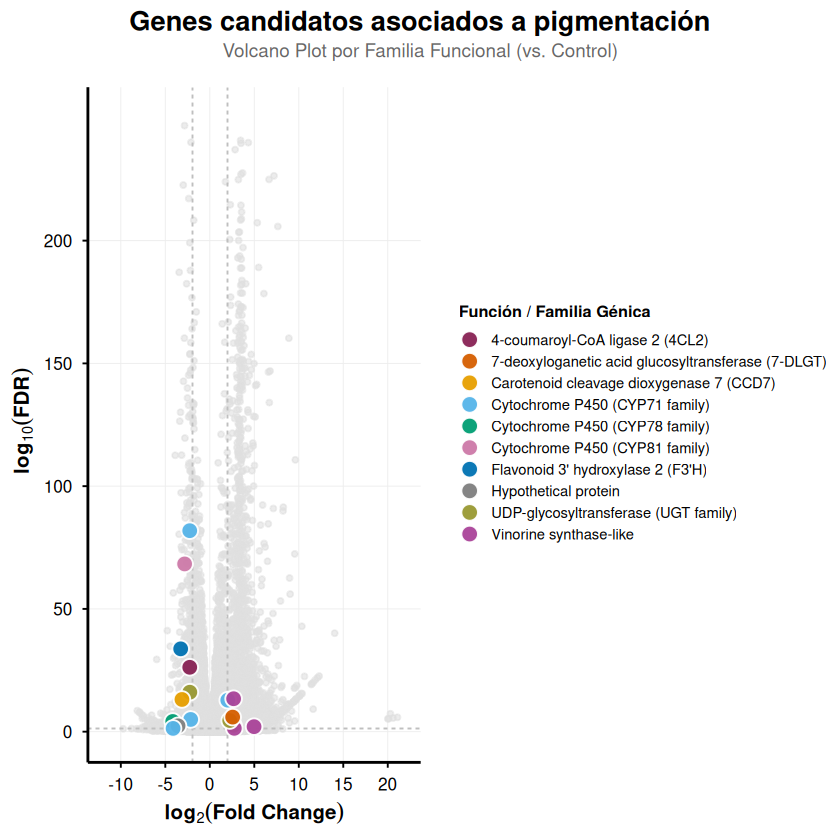

In [ ]:
#=========================================================
# Volcano Plot transcritos asociados a pigmentos
#=========================================================
p_functions <- ggplot() +

  geom_point(
    data = genes_fondo,
    aes(x = log2FoldChange, y = -log10(padj)),
    color = "grey88",
    size = 1.0,        
    alpha = 0.6
  ) +

  geom_vline(xintercept = c(-lfc_cutoff, lfc_cutoff), linetype = "dashed", color = "grey75", size = 0.4) +
  geom_hline(yintercept = -log10(padj_cutoff), linetype = "dashed", color = "grey75", size = 0.4) +

  geom_point(
    data = genes_color,
    aes(x = log2FoldChange, y = -log10(padj), fill = family),
    shape = 21,         
    color = "white",    
    stroke = 0.6,       
    size = 4.0,         
    alpha = 0.95
  ) +

  scale_fill_manual(
    name = "Función / Familia Génica",
    values = colores_familias
  ) +

  ##  ejes y títulos
  labs(
    title = "Genes candidatos asociados a pigmentación",
    subtitle = "Volcano Plot por Familia Funcional (vs. Control)",
    x = expression(bold(log[2]("Fold Change"))),
    y = expression(bold(-log[10]("FDR")))
  ) +

  scale_x_continuous(limits = c(-12, 22), breaks = seq(-10, 20, by = 5)) +
  scale_y_continuous(limits = c(0, 250), breaks = seq(0, 200, by = 50)) +

  theme_minimal(base_size = 13) +
  theme(

    plot.title.position = "plot",    
    plot.subtitle.position = "plot", 
    plot.title = element_text(face = "bold", hjust = 0.5, size = 16, color = "black"),
    plot.subtitle = element_text(hjust = 0.5, size = 11, color = "grey40", margin = margin(t = -3, b = 15)),
    
    # Ejes
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(size = 10, color = "black"),
    axis.line = element_line(size = 0.6, color = "black"),
    axis.ticks = element_line(size = 0.4, color = "black"),

    # leyenda lateral
    legend.position = "right",
    legend.title = element_text(face = "bold", size = 9.5), 
    legend.text = element_text(size = 8.5),                 
    legend.key.size = unit(0.9, "lines"), 
    legend.margin = margin(0, 0, 0, 10),
    
    # Cuadricula
    panel.grid.major = element_line(size = 0.2, color = "grey93"),
    panel.grid.minor = element_blank()
  )


ggsave(
  "Volcano_Pigment_Families_Proportional.png",
  plot = p_functions,
  width = 11.0,    
  height = 7.0,
  dpi = 300,
  bg = "white"
)

print(p_functions)

Número de KO en map00906: 23 
Número de genes asociados: 67 


,gene,KO,logFC,pfam_desc,ipr_desc
,<chr>,<chr>,<dbl>,<chr>,<chr>
1,pelegrina_gene1524295_i4,K02291,6.281576,Squalene/phytoene synthase; BIFUNCTIONAL LYCOPENE CYCLASE/PHYTOENE SYNTHASE,Squalene/phytoene synthase; -
2,pelegrina_gene1329388_i7,K17912,-3.127487,Retinal pigment epithelial membrane protein; BETA-CAROTENE DIOXYGENASE,Carotenoid oxygenase
3,pelegrina_gene1326677_i1,K09840,-2.227015,BETA-CAROTENE DIOXYGENASE; Retinal pigment epithelial membrane protein,Carotenoid oxygenase
4,pelegrina_gene1913075_i12,K15746,2.097965,"BETA-CAROTENE 3-HYDROXYLASE 1, CHLOROPLASTIC; Fatty acid hydroxylase",Beta-carotene hydroxylase-like; Fatty acid hydroxylase
5,pelegrina_gene844081_i1,K15746,2.025221,"Fatty acid hydroxylase; BETA-CAROTENE 3-HYDROXYLASE 1, CHLOROPLASTIC",Fatty acid hydroxylase; Beta-carotene hydroxylase-like
6,pelegrina_gene1172939_i5,K15746,1.951377,"BETA-CAROTENE 3-HYDROXYLASE 1, CHLOROPLASTIC; Fatty acid hydroxylase",Beta-carotene hydroxylase-like; Fatty acid hydroxylase
7,pelegrina_gene1900960_i11,K17912,-1.869291,BETA-CAROTENE DIOXYGENASE; Retinal pigment epithelial membrane protein,Carotenoid oxygenase
8,pelegrina_gene1181830_i2,K09843,1.832057,Cytochrome P450; CYTOCHROME P450 26,Cytochrome P450; -
9,pelegrina_gene33277_i1,K15746,1.720741,"BETA-CAROTENE 3-HYDROXYLASE 1, CHLOROPLASTIC; Fatty acid hydroxylase",Beta-carotene hydroxylase-like; Fatty acid hydroxylase


# A tibble: 18 × 5
   KO     n_genes max_abs_logFC mean_logFC example_function                     
   <chr>    <int>         <dbl>      <dbl> <chr>                                
 1 K02291      13        6.28       0.276  Squalene/phytoene synthase; -        
 2 K17912       2        3.13      -2.50   Carotenoid oxygenase                 
 3 K09840       6        2.23      -0.954  Carotenoid oxygenase                 
 4 K15746       4        2.10       1.95   Beta-carotene hydroxylase-like; Fatt…
 5 K09843       4        1.83       0.897  Cytochrome P450; -                   
 6 K17911       6        1.69       0.370  Beta-carotene isomerase D27-like, C-…
 7 K15747       2        1.15       0.607  Cytochrome P450 Monooxygenases; Cyto…
 8 K00514       6        0.828      0.0468 Amine oxidase; Zeta Carotene Desatur…
 9 K06443       5        0.663      0.345  -; Lycopene cyclase, beta/epsilon    
10 K09837       2        0.644      0.440  Cytochrome P450; Cytochrome P450 Mon…
11 K09838

Note: Only KEGG ortholog gene ID is supported, make sure it looks like "K01488"!

Note: Mapping via KEGG gene ID (not Entrez) is supported for this species,
it looks like "K01488"!

Info: Working in directory /home/pazzz/Escritorio/GTF/DE_alstroemeria/DEA

Info: Writing image file ko00906.pathview.png



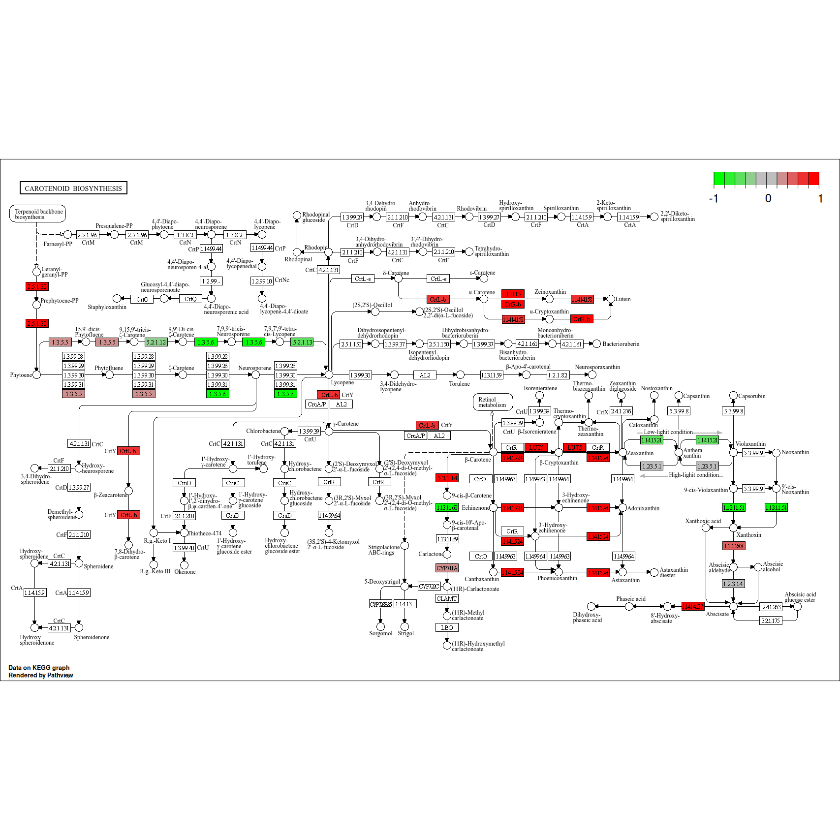

In [24]:
# =====================================================
# GENES DE LA RUTA map00906
# Carotenoid biosynthesis
# =====================================================

library(dplyr)
library(pathview)
library(png)
library(grid)

# =====================================================
# Cargar InterProScan
# =====================================================

interpro <- read.delim(
  "/home/pazzz/Escritorio/GTF/DE_alstroemeria/anotacionInterpro/pelegrina_pf.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(interpro) <- c(
  "gene","md5","length","db","pfam","pfam_desc",
  "start","end","evalue","status","date",
  "ipr","ipr_desc","go","pathway"
)

interpro$gene <- sub("\\.p[0-9]+$", "", interpro$gene)

interpro_unique <- interpro %>%
  group_by(gene) %>%
  summarise(
    pfam = paste(unique(na.omit(pfam)), collapse="; "),
    pfam_desc = paste(unique(na.omit(pfam_desc)), collapse="; "),
    ipr = paste(unique(na.omit(ipr)), collapse="; "),
    ipr_desc = paste(unique(na.omit(ipr_desc)), collapse="; "),
    .groups="drop"
  )

# =====================================================
# KO presentes en map00906
# =====================================================

ko_00906 <- unique(
  gene2path$KO[
    gene2path$Pathway == "map00906"
  ]
)

cat("Número de KO en map00906:", length(ko_00906), "\n")

# =====================================================
# Genes asociados
# =====================================================

genes_00906 <- gene_fc_ko %>%
  filter(KO %in% ko_00906)

cat(
  "Número de genes asociados:",
  length(unique(genes_00906$gene)),
  "\n"
)

# =====================================================
# Unir con InterPro
# =====================================================

genes_00906_clean <- genes_00906 %>%
  left_join(interpro_unique, by="gene") %>%
  distinct(gene, KO, logFC, .keep_all=TRUE) %>%
  arrange(desc(abs(logFC)))

# =====================================================
# Top genes
# =====================================================

genes_00906_clean %>%
  select(
    gene,
    KO,
    logFC,
    pfam_desc,
    ipr_desc
  ) %>%
  head(20)

# =====================================================
# Guardar tabla completa
# =====================================================

write.csv(
  genes_00906_clean,
  "Carotenoid_biosynthesis_genes_annotated.csv",
  row.names = FALSE
)

# =====================================================
# Resumen por KO
# =====================================================

ko_summary_00906 <- genes_00906_clean %>%
  group_by(KO) %>%
  summarise(
    n_genes = n(),
    max_abs_logFC = max(abs(logFC), na.rm=TRUE),
    mean_logFC = mean(logFC, na.rm=TRUE),
    example_function = first(
      ipr_desc[!is.na(ipr_desc) & ipr_desc != ""]
    ),
    .groups="drop"
  ) %>%
  arrange(desc(max_abs_logFC))

print(
  ko_summary_00906,
  n = nrow(ko_summary_00906)
)

# =====================================================
# DEGs importantes
# =====================================================

genes_00906_deg <- genes_00906_clean %>%
  filter(
    abs(logFC) >= 2,
    padj < 0.01
  )

cat(
  "\nGenes con |logFC| >= 2:",
  nrow(genes_00906_deg),
  "\n"
)

write.csv(
  genes_00906_deg,
  "Carotenoid_biosynthesis_DEGs.csv",
  row.names = FALSE
)

# =====================================================
# KO presentes
# =====================================================

cat("\nKO presentes en map00906:\n")

print(
  sort(unique(genes_00906_clean$KO))
)

# =====================================================
# Pathview
# =====================================================

fc_vector_00906 <- genes_00906 %>%
  group_by(KO) %>%
  slice_max(
    abs(logFC),
    n = 1,
    with_ties = FALSE
  ) %>%
  ungroup()

fc_vector <- fc_vector_00906$logFC
names(fc_vector) <- fc_vector_00906$KO

pathview(
  gene.data = fc_vector,
  pathway.id = "00906",
  species = "ko",
  kegg.native = TRUE
)

# =====================================================
# Mostrar imagen en Jupyter
# =====================================================

img <- readPNG("ko00906.pathview.png")

grid.newpage()
grid.raster(img)

In [25]:
genes_00906_deg %>%
  select(
    gene,
    KO,
    logFC,
    padj,
    ipr_desc
  ) %>%
  arrange(desc(abs(logFC)))

gene,KO,logFC,padj,ipr_desc
<chr>,<chr>,<dbl>,<dbl>,<chr>
pelegrina_gene1524295_i4,K02291,6.281576,5.342177e-05,Squalene/phytoene synthase; -
pelegrina_gene1329388_i7,K17912,-3.127487,7.602893e-14,Carotenoid oxygenase
pelegrina_gene1326677_i1,K09840,-2.227015,6.112544e-107,Carotenoid oxygenase
pelegrina_gene1913075_i12,K15746,2.097965,1.304404e-91,Beta-carotene hydroxylase-like; Fatty acid hydroxylase
pelegrina_gene844081_i1,K15746,2.025221,1.217651e-84,Fatty acid hydroxylase; Beta-carotene hydroxylase-like


CANDIDATOS 
| KO     | logFC |       padj | Función                 | id                        |   
| ------ | ----: | ---------: | ----------------------- |-------------------------- |
| K02291 |  6.28 |   5.3×10⁻⁵ | Phytoene synthase (PSY) | pelegrina_gene1524295_i4  |
| K17912 | -3.13 |  7.6×10⁻¹⁴ | Carotenoid oxygenase    | pelegrina_gene1329388_i7  | 
| K09840 | -2.23 | 6.1×10⁻¹⁰⁷ | Carotenoid oxygenase    | pelegrina_gene1326677_i1  |
| K15746 |  2.10 |  1.3×10⁻⁹¹ | β-carotene hydroxylase  | pelegrina_gene1913075_i12 | 
| K15746 |  2.03 |  1.2×10⁻⁸⁴ | β-carotene hydroxylase  | pelegrina_gene844081_i1   | 


  CANDIDATOS PARA MSA
  
   K02291      13        6.28       0.276  Squalene/phytoene synthase; -        
 2 K17912       2        3.13      -2.50   Carotenoid oxygenase                 
 3 K09840       6        2.23      -0.954  Carotenoid oxygenase                 
 4 K15746       4        2.10       1.95   Beta-carotene hydroxylase-like; Fatt

CANDIDATOS PARA FENILPROPANIDES

In [26]:
# =====================================================
# GENES DE LA RUTA map00940
# Phenylpropanoid biosynthesis
# =====================================================

library(dplyr)
library(pathview)
library(png)
library(grid)

# =====================================================
# Cargar InterProScan
# =====================================================

interpro <- read.delim(
  "/home/pazzz/Escritorio/GTF/DE_alstroemeria/anotacionInterpro/pelegrina_pf.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(interpro) <- c(
  "gene","md5","length","db","pfam","pfam_desc",
  "start","end","evalue","status","date",
  "ipr","ipr_desc","go","pathway"
)

interpro$gene <- sub("\\.p[0-9]+$", "", interpro$gene)

interpro_unique <- interpro %>%
  group_by(gene) %>%
  summarise(
    pfam = paste(unique(na.omit(pfam)), collapse="; "),
    pfam_desc = paste(unique(na.omit(pfam_desc)), collapse="; "),
    ipr = paste(unique(na.omit(ipr)), collapse="; "),
    ipr_desc = paste(unique(na.omit(ipr_desc)), collapse="; "),
    .groups="drop"
  )

# =====================================================
# KO presentes en map00940
# =====================================================

ko_00940 <- unique(
  gene2path$KO[
    gene2path$Pathway == "map00940"
  ]
)

cat(
  "Número de KO en map00940:",
  length(ko_00940),
  "\n"
)

# =====================================================
# Genes asociados
# =====================================================

genes_00940 <- gene_fc_ko %>%
  filter(KO %in% ko_00940)

cat(
  "Número de genes asociados:",
  length(unique(genes_00940$gene)),
  "\n"
)

# =====================================================
# Unir con InterPro
# =====================================================

genes_00940_clean <- genes_00940 %>%
  left_join(
    interpro_unique,
    by = "gene"
  ) %>%
  distinct(
    gene,
    KO,
    logFC,
    .keep_all = TRUE
  ) %>%
  arrange(
    desc(abs(logFC))
  )

# =====================================================
# Top genes
# =====================================================

genes_00940_clean %>%
  select(
    gene,
    KO,
    logFC,
    pfam_desc,
    ipr_desc
  ) %>%
  head(20)

# =====================================================
# Guardar tabla completa
# =====================================================

write.csv(
  genes_00940_clean,
  "Phenylpropanoid_biosynthesis_genes_annotated.csv",
  row.names = FALSE
)

# =====================================================
# Resumen por KO
# =====================================================

ko_summary_00906 <- genes_00906_deg %>%
  group_by(KO) %>%
  summarise(
    n_genes = n(),
    max_abs_logFC = max(abs(logFC), na.rm = TRUE),
    mean_logFC = mean(logFC, na.rm = TRUE),

    example_function =
      paste(
        unique(
          na.omit(ipr_desc)
        )[1],
        collapse = ""
      ),

    .groups = "drop"
  ) %>%
  arrange(desc(max_abs_logFC))

print(
  ko_summary_00940,
  n = nrow(ko_summary_00940)
)

# =====================================================
# DEGs importantes
# =====================================================

genes_00940_deg <- genes_00940_clean %>%
  filter(abs(logFC) >= 2)

cat(
  "\nGenes con |logFC| >= 2:",
  nrow(genes_00940_deg),
  "\n"
)

write.csv(
  genes_00940_deg,
  "Phenylpropanoid_biosynthesis_DEGs.csv",
  row.names = FALSE
)

# =====================================================
# KO presentes
# =====================================================

cat("\nKO presentes en map00940:\n")

print(
  sort(
    unique(
      genes_00940_clean$KO
    )
  )
)

# =====================================================
# Crear vector KO -> logFC
# =====================================================

fc_vector_00940 <- genes_00940 %>%
  group_by(KO) %>%
  slice_max(
    abs(logFC),
    n = 1,
    with_ties = FALSE
  ) %>%
  ungroup()

fc_vector <- fc_vector_00940$logFC
names(fc_vector) <- fc_vector_00940$KO

# =====================================================
# Pathview
# =====================================================

pathview(
  gene.data = fc_vector,
  pathway.id = "00940",
  species = "ko",
  kegg.native = TRUE
)

# =====================================================
# Mostrar imagen en Jupyter
# =====================================================

img <- readPNG(
  "ko00940.pathview.png"
)

grid.newpage()
grid.raster(img)

Número de KO en map00940: 15 
Número de genes asociados: 158 


,gene,KO,logFC,pfam_desc,ipr_desc
,<chr>,<chr>,<dbl>,<chr>,<chr>
1,pelegrina_gene1193322_i2,K00430,5.610644,PEROXIDASE 25-RELATED; Peroxidase,Plant peroxidase; Haem peroxidase
2,pelegrina_gene16189_i16,K00430,5.228631,Peroxidase; PEROXIDASE 25-RELATED,Haem peroxidase; Plant peroxidase
3,pelegrina_gene1163355_i1,K00430,4.969368,Peroxidase; -,Haem peroxidase; Plant peroxidase
4,pelegrina_gene1040488_i1,K00430,4.938818,Peroxidase; PEROXIDASE 25-RELATED,Haem peroxidase; Plant peroxidase
5,pelegrina_gene1454240_i2,K00430,4.794513,-; Peroxidase,Plant peroxidase; Haem peroxidase
6,pelegrina_gene1034172_i8,K00430,4.219143,Peroxidase; -,Haem peroxidase; Plant peroxidase
7,pelegrina_gene1942788_i1,K18368,-4.198051,"PHOSPHOLIPASE-RELATED; Serine aminopeptidase, S33","Monoacylglycerol and Diacylglycerol Lipase; Serine aminopeptidase, S33"
8,pelegrina_gene861453_i1,K00430,3.951160,-; Peroxidase,Plant peroxidase; Haem peroxidase
9,pelegrina_gene1311285_i1,K01904,-3.742951,LONG-CHAIN-FATTY-ACID--COA LIGASE; AMP-binding enzyme; AMP-binding enzyme C-terminal domain,"-; AMP-dependent synthetase/ligase domain; AMP-binding enzyme, C-terminal domain"


ERROR: Error: objeto 'ko_summary_00940' no encontrado


CANDIDATOS:
Ruta fenilpropanoides

K00083

cinnamyl alcohol dehydrogenase

K01904

4-coumarate-CoA ligase

K00430

peroxidases con logFC extremos

CUTIN S, WAX 

Número de KO en map00073: 13 
Número de genes asociados: 158 


,gene,KO,logFC,pfam_desc,ipr_desc
,<chr>,<chr>,<dbl>,<chr>,<chr>
1,pelegrina_gene1181382_i2,K17991,6.631554,Caleosin related protein; PEROXYGENASE 3-RELATED,Caleosin-related
2,pelegrina_gene1308325_i7,K15402,-5.969803,CYTOCHROME P450; Cytochrome P450,-; Cytochrome P450
3,pelegrina_gene1195639_i3,K15402,-4.776537,CYTOCHROME P450; Cytochrome P450,-; Cytochrome P450
4,pelegrina_gene101746_i1,K13356,4.034315,MALE STERILITY PROTEIN 2-RELATED; Male sterility protein,"Fatty acyl-CoA reductase; Fatty acyl-CoA reductase-like, NAD-binding domain"
5,pelegrina_gene1911836_i1,K17991,-3.241471,PEROXYGENASE 3-RELATED; Caleosin related protein,Caleosin-related
6,pelegrina_gene1904345_i4,K15401,2.844183,Cytochrome P450; CYTOCHROME P450,Cytochrome P450; -
7,pelegrina_gene888643_i1,K27538,-2.136707,TRANSMEMBRANE PROTEIN 68; Diacylglycerol acyltransferase,-; Diacylglycerol acyltransferase
8,pelegrina_gene837149_i6,K15402,-2.039932,Cytochrome P450; CYTOCHROME P450,Cytochrome P450; -
9,pelegrina_gene1324587_i4,K17991,-1.893383,PEROXYGENASE 3-RELATED; Caleosin related protein,Caleosin-related


# A tibble: 11 × 5
   KO     n_genes max_abs_logFC mean_logFC example_function                     
   <chr>    <int>         <dbl>      <dbl> <chr>                                
 1 K17991      15         6.63     -0.380  Caleosin-related                     
 2 K15402       4         5.97     -3.46   -; Cytochrome P450                   
 3 K13356       8         4.03      0.0961 Fatty acyl-CoA reductase; Fatty acyl…
 4 K15401       1         2.84      2.84   Cytochrome P450; -                   
 5 K27538       7         2.14     -0.158  -; Diacylglycerol acyltransferase    
 6 K15404       9         1.74      0.336  Fatty acid hydroxylase; Sterol Desat…
 7 K15398       2         1.23      0.159  -; Cytochrome P450                   
 8 K15400       4         1.08     -0.793  -; Plant and Fungal Acyltransferase  
 9 K15403       2         0.861    -0.547  -; Myb/SANT-like DNA-binding domain …
10 K21995       4         0.744    -0.307  -; Cytochrome P450                   
11 K28799

Note: Only KEGG ortholog gene ID is supported, make sure it looks like "K01488"!

Note: Mapping via KEGG gene ID (not Entrez) is supported for this species,
it looks like "K01488"!

Info: Working in directory /home/pazzz/Escritorio/GTF/DE_alstroemeria/DEA

Info: Writing image file ko00073.pathview.png



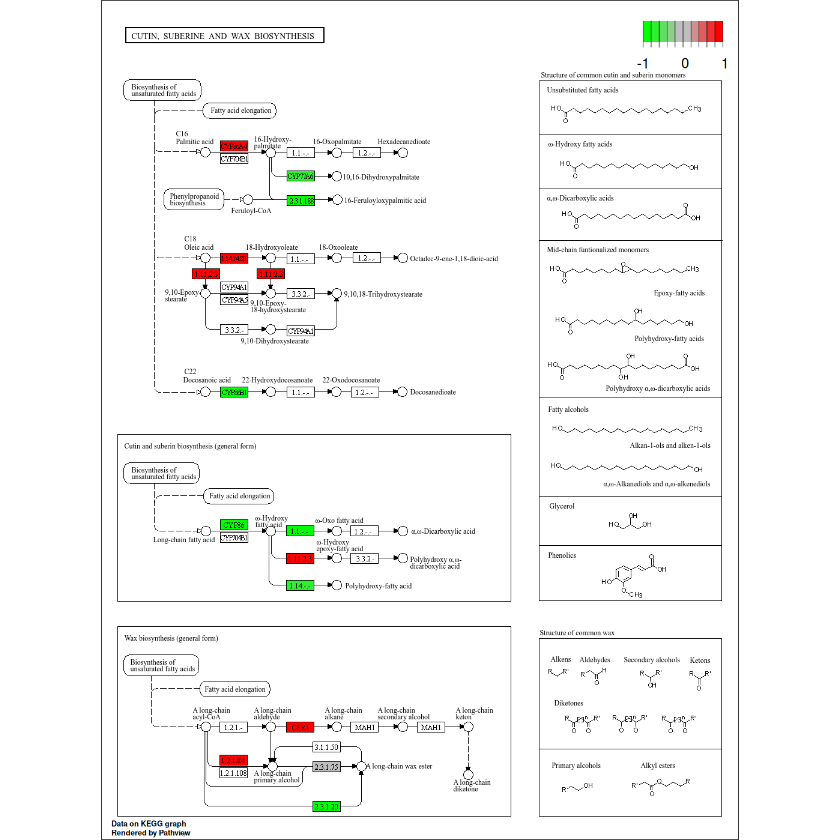

In [ ]:
# =====================================================
# GENES DE LA RUTA map00073
# =====================================================

library(dplyr)
library(pathview)
library(png)
library(grid)

# =====================================================
# Cargar InterProScan
# =====================================================

interpro <- read.delim(
  "/home/pazzz/Escritorio/GTF/DE_alstroemeria/anotacionInterpro/pelegrina_pf.tsv",
  header = FALSE,
  sep = "\t",
  stringsAsFactors = FALSE
)

colnames(interpro) <- c(
  "gene","md5","length","db","pfam","pfam_desc",
  "start","end","evalue","status","date",
  "ipr","ipr_desc","go","pathway"
)

interpro$gene <- sub("\\.p[0-9]+$", "", interpro$gene)

interpro_unique <- interpro %>%
  group_by(gene) %>%
  summarise(
    pfam = paste(unique(na.omit(pfam)), collapse="; "),
    pfam_desc = paste(unique(na.omit(pfam_desc)), collapse="; "),
    ipr = paste(unique(na.omit(ipr)), collapse="; "),
    ipr_desc = paste(unique(na.omit(ipr_desc)), collapse="; "),
    .groups="drop"
  )

# =====================================================
# KO presentes en map00073
# =====================================================

ko_00073 <- unique(
  gene2path$KO[
    gene2path$Pathway == "map00073"
  ]
)

cat(
  "Número de KO en map00073:",
  length(ko_00073),
  "\n"
)

# =====================================================
# Genes asociados
# =====================================================

genes_00073 <- gene_fc_ko %>%
  filter(KO %in% ko_00073)

cat(
  "Número de genes asociados:",
  length(unique(genes_00940$gene)),
  "\n"
)

# =====================================================
# Unir con InterPro
# =====================================================

genes_00073_clean <- genes_00073 %>%
  left_join(
    interpro_unique,
    by = "gene"
  ) %>%
  distinct(
    gene,
    KO,
    logFC,
    .keep_all = TRUE
  ) %>%
  arrange(
    desc(abs(logFC))
  )

# =====================================================
# Top genes
# =====================================================

genes_00073_clean %>%
  select(
    gene,
    KO,
    logFC,
    pfam_desc,
    ipr_desc
  ) %>%
  head(20)

# =====================================================
# Guardar tabla completa
# =====================================================

write.csv(
  genes_00073_clean,
  "cutin_wax_genes_annotated.csv",
  row.names = FALSE
)

# =====================================================
# Resumen por KO
# =====================================================

ko_summary_00073 <- genes_00073_clean %>%
  group_by(KO) %>%
  summarise(
    n_genes = n(),
    max_abs_logFC = max(abs(logFC), na.rm = TRUE),
    mean_logFC = mean(logFC, na.rm = TRUE),

    example_function =
      paste(
        unique(
          na.omit(ipr_desc)
        )[1],
        collapse = ""
      ),

    .groups = "drop"
  ) %>%
  arrange(desc(max_abs_logFC))

print(
  ko_summary_00073,
  n = nrow(ko_summary_00073)
)

# =====================================================
# DEGs importantes
# =====================================================

genes_00073_deg <- genes_00073_clean %>%
  filter(abs(logFC) >= 2)

cat(
  "\nGenes con |logFC| >= 2:",
  nrow(genes_00073_deg),
  "\n"
)

write.csv(
  genes_00073_deg,
  "cutin_wax_DEGs.csv",
  row.names = FALSE
)

# =====================================================
# KO presentes
# =====================================================

cat("\nKO presentes en map00073:\n")

print(
  sort(
    unique(
      genes_00940_clean$KO
    )
  )
)

# =====================================================
# Crear vector KO -> logFC
# =====================================================

fc_vector_00073 <- genes_00073 %>%
  group_by(KO) %>%
  slice_max(
    abs(logFC),
    n = 1,
    with_ties = FALSE
  ) %>%
  ungroup()

fc_vector <- fc_vector_00073$logFC
names(fc_vector) <- fc_vector_00073$KO

# =====================================================
# Pathview
# =====================================================

pathview(
  gene.data = fc_vector,
  pathway.id = "00073",
  species = "ko",
  kegg.native = TRUE
)

# =====================================================
# Mostrar imagen en Jupyter
# =====================================================

img <- readPNG(
  "ko00073.pathview.png"
)

grid.newpage()
grid.raster(img)

In [ ]:
# Leer DEGs
deg <- read.csv(
  "DEG_ASW_vs_ASWO_logFC2.csv",
  row.names = 1,
  check.names = FALSE
)

# Convertir rownames a columna
deg$GeneID <- rownames(deg)

# Leer anotación
anno <- read.delim(
  "anotacion_integrada.tsv",
  header = FALSE,
  stringsAsFactors = FALSE
)

# Asignar nombres de columnas
colnames(anno) <- c(
  "GeneID","Accession","Evalue","Bitscore","Identity",
  "AlignLen","Qstart","Qend","Sstart","Send",
  "Slen","Cov","Qcov","Frame1","Frame2",
  "Description","Functional_annotation"
)

# Unir tablas
deg_annot <- merge(
  deg,
  anno,
  by = "GeneID",
  all.x = TRUE
)

# Guardar resultado
write.csv(
  deg_annot,
  "DEG_ASW_vs_ASWO_logFC2_anotado.csv",
  row.names = FALSE
)

In [ ]:
deg <- read.csv("DEG_ASW_vs_ASWO_logFC2.csv",
                row.names = 1,
                check.names = FALSE)

deg$GeneID <- rownames(deg)

anno <- read.delim("anotacion_integrada.tsv",
                   header = FALSE,
                   stringsAsFactors = FALSE)

sum(deg$GeneID %in% anno$V1)

[1] 335

In [ ]:
library(ggplot2)
library(dplyr)
library(stringr)

# 1. Filtrar y preparar los datos directamente en un data.frame
plot_data <- as.data.frame(kegg_enrich) %>%
  filter(ID %in% c("map00940", "map00946", "map00906", "map00999")) %>%
  # Limpiar el nombre de las rutas (ej. quitar " - Organism name" si lo tuviera)
  mutate(Description = str_replace(Description, " - .*$", "")) %>%
  # Asegurar que el orden de las barras dependa de la significancia (p.adjust)
  mutate(Description = reorder(Description, Count))

# 2. Construcción del gráfico con ggplot2
p <- ggplot(plot_data, aes(x = Count, y = Description, fill = p.adjust)) +
  # Barras con bordes limpios y ancho controlado
  geom_col(width = 0.65, color = "black", size = 0.2) +
  # Paleta de colores científica y legible (Viridis es excelente para papers)
  scale_fill_viridis_c(
    option = "plasma", 
    direction = -1,
    name = expression(italic("p") * "-adjust")
  ) +
  # Etiquetas claras y formales
  labs(
    x = "Number of Genes (Count)",
    y = "KEGG Pathway",
    title = "Enrichment of Pigment-Related Pathways",
    subtitle = "Significantly enriched categories based on differential expression"
  ) +
  # Aplicar un tema minimalista y limpio (Theme Publication)
  theme_minimal(base_size = 12, base_family = "sans") + 
  theme(
    # Eliminar líneas de cuadrícula secundarias y del eje Y para limpiar el fondo
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_line(color = "gray92", linetype = "dashed"),
    # Ajustes de los ejes (línea del eje Y sólida)
    axis.line.y = element_line(color = "black", size = 0.5),
    axis.ticks.y = element_line(color = "black"),
    # Formato de textos
    axis.text = element_text(color = "black", face = "plain"),
    axis.title = element_text(color = "black", face = "bold"),
    plot.title = element_text(face = "bold", size = 14, margin = margin(b = 5)),
    plot.subtitle = element_text(color = "gray30", size = 10, margin = margin(b = 15)),
    # Ajustes de la leyenda
    legend.position = "right",
    legend.title = element_text(size = 10, face = "bold"),
    legend.background = element_blank()
  )

# 3. Guardar en alta resolución y formato vectorial (opcional pero recomendado)
# Nota: Guardar en .pdf o .svg es el estándar para revistas científicas.
ggsave(
  "KEGG_Barplot_Pigment_Pathways_Publication.pdf",
  plot = p,
  width = 8,
  height = 5,
  device = "pdf",
  useDingbats = FALSE
)

# También guardamos la versión PNG por si la necesitas rápido
ggsave(
  "KEGG_Barplot_Pigment_Pathways_Publication.png",
  plot = p,
  width = 8,
  height = 5,
  dpi = 300
)

Warning message in geom_col(width = 0.65, color = "black", size = 0.2):
“Ignoring unknown parameters: `size`”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


In [ ]:
library(KEGGREST)

kos <- unique(genes_00906_clean$KO)

ko_ec <- lapply(kos, function(k){

  info <- keggGet(k)[[1]]

  data.frame(
    KO = k,
    EC = paste(info$ENZYME, collapse=";"),
    NAME = info$NAME[1]
  )

})

ko_ec <- do.call(rbind, ko_ec)
ko_ec

KO,EC,NAME
<chr>,<chr>,<chr>
K02291,,15-cis-phytoene synthase [EC:2.5.1.32]
K17912,,"9-cis-beta-carotene 9',10'-cleaving dioxygenase [EC:1.13.11.68]"
K09840,,9-cis-epoxycarotenoid dioxygenase [EC:1.13.11.51]
K15746,,beta-carotene 3-hydroxylase [EC:1.14.15.24]
K09843,,(+)-abscisic acid 8'-hydroxylase [EC:1.14.14.137]
K17911,,beta-carotene isomerase [EC:5.2.1.14]
K15747,,beta-ring hydroxylase [EC:1.14.-.-]
K00514,,zeta-carotene desaturase [EC:1.3.5.6]
K06443,,lycopene beta-cyclase [EC:5.5.1.19]
